# Tema : Modelos ARCH/GARCH
![](src/img/logo_utb.png){width=40%} 
![](src/img/logo_etd.png){width=40%}
- **Profesor:**
- **Fernando Salcedo Mejía, Eco Msc.**
- Programa de Ciencias de Datos | Escuela de transformación digital.
- 2026-1

In [43]:
# Librerias necesarias

# Datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

# Modelos de tiempo
from arch import arch_model

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.stattools import jarque_bera, durbin_watson

import warnings
warnings.filterwarnings('ignore')


### Ejercicio 1. Modelación de los precios de Google.

Usando los datos de precios de cierre de Google en la bolsa de valores, estimar un modelo ARCH/GARCH


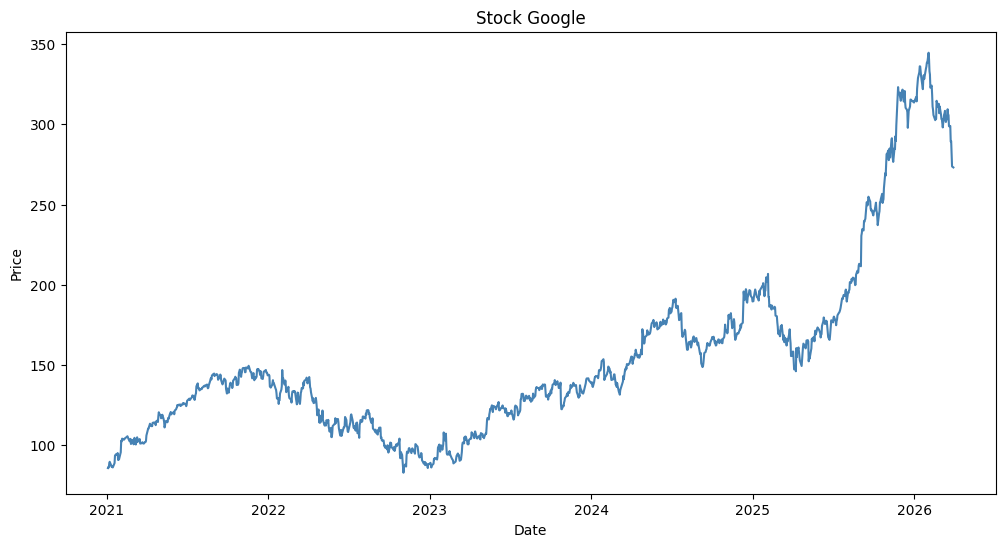

In [41]:
# Descargar los datos del Banco Mundial
# Descargar datos de la serie de tiempo
df = yf.download('GOOG', start='2021-01-01', end='2026-03-31', progress=False)
df = df['Close']
df.index = pd.to_datetime(df.index)
price_google = df.GOOG

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(price_google.index, price_google, color='steelblue')
ax.set_title('Stock Google')
ax.set_xlabel('Date')
ax.set_ylabel('Price')
plt.show()

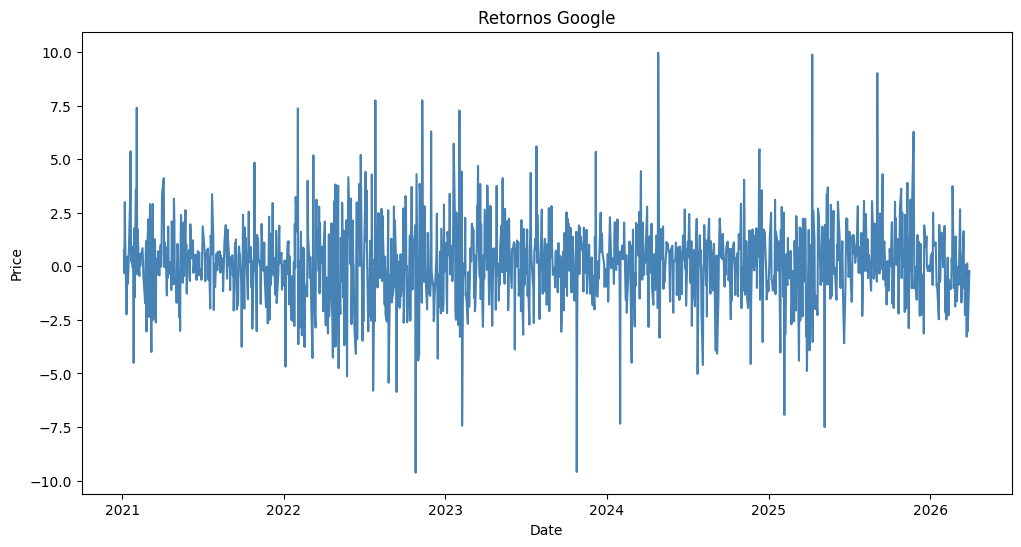

In [42]:
# retornos
retornos = 100 * price_google.pct_change().dropna()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(retornos.index, retornos, color='steelblue')
ax.set_title('Retornos Google')
ax.set_xlabel('Date')
ax.set_ylabel('Price')
plt.show()

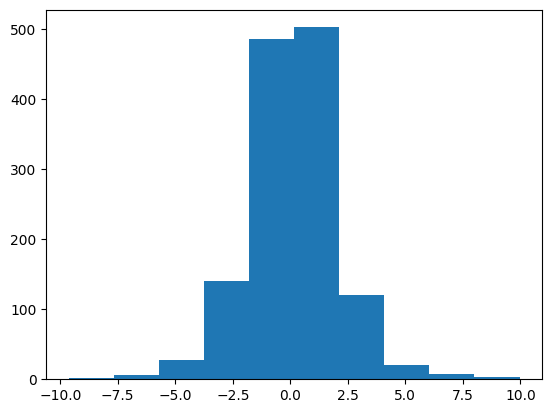

In [25]:
# Distribución de los retornos. Suelen tener colas largas.
fig = plt.hist(retornos)

In [26]:
# Prueba de Dickey-Fuller Aumentada (ADF): Verifica que tus retornos sean estacionarios
def test_estacionariedad(datos):
    # Augmented Dickey-Fuller
    adf_result = adfuller(datos)
    # KPSS
    kpss_result = kpss(datos, regression='c')

    # Tabla de resultados
    tab_test = pd.DataFrame({
        'Test'        : ["Prueba Augmented Dickey-Fuller (ADF)", "Prueba KPSS"],
        'Estadístico' : [round(adf_result[0],  4), round(kpss_result[0],  4)],
        'P-valor'     : [round(adf_result[1], 4), round(kpss_result[1], 4)],
        "Estacionario" : ["Sí" if adf_result[1] < 0.05 else "No", "No" if kpss_result[1] < 0.05 else "Sí"]
    })

    print("=" * 80)
    print("PRUEBA DE ESTACIONARIEDAD")
    print("=" * 80)
    print(tab_test)
    print("=" * 80)


test_estacionariedad(retornos)

PRUEBA DE ESTACIONARIEDAD
                                   Test  Estadístico  P-valor Estacionario
0  Prueba Augmented Dickey-Fuller (ADF)     -36.3215      0.0           Sí
1                           Prueba KPSS       0.1088      0.1           Sí


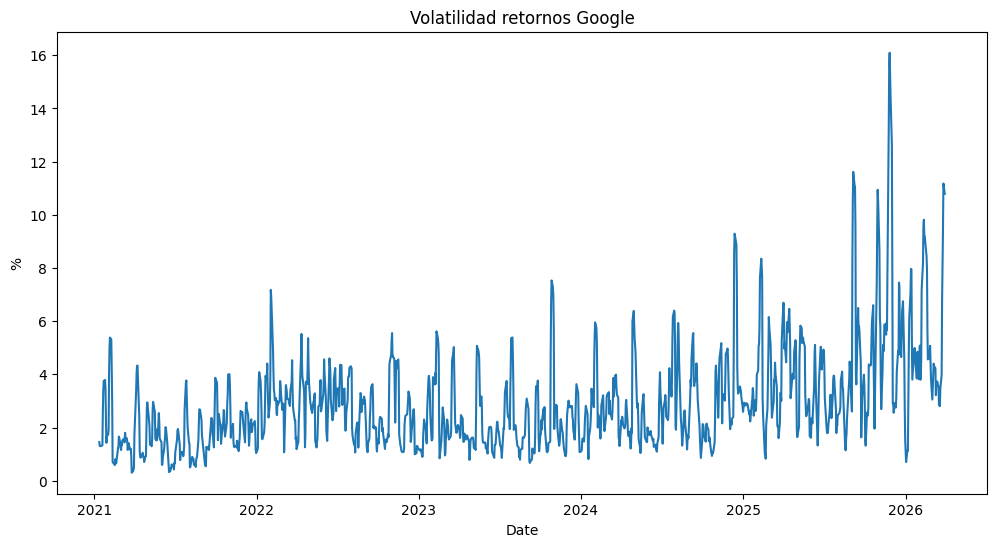

In [27]:
# Estimar de volatilidad Inspección visual de std móvil
# ventana semanal
ventana = 7
varianza_movil = pd.Series(price_google).rolling(ventana).std()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(varianza_movil.index, varianza_movil)
ax.set_title('Volatilidad retornos Google')
ax.set_xlabel('Date')
ax.set_ylabel('%')
plt.show()

In [51]:
# Prueba de Multiplicador de Lagrange (LM) de Engle
from statsmodels.stats.diagnostic import het_arch

model_fit = ARIMA(retornos, order=(1, 0, 0)).fit()
residuos = model_fit.resid
arch_test = het_arch(residuos, nlags=10)

labels = ['Estadístico LM', 'p-value LM', 'Estadístico F', 'p-value F']
print(dict(zip(labels, arch_test)))


{'Estadístico LM': 15.414259732307713, 'p-value LM': 0.1176727161171734, 'Estadístico F': 1.5467063782448325, 'p-value F': 0.11739186998176201}


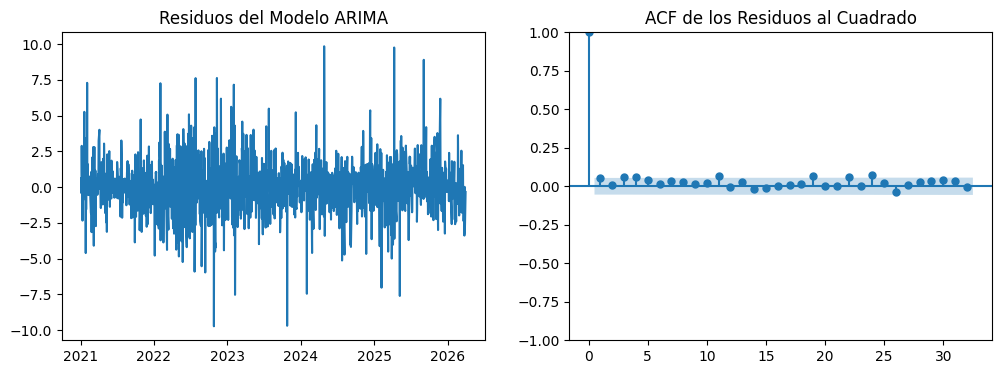

In [39]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Visualizar residuos: ¿Se ve volatilidad agrupada?
ax[0].plot(residuos)
ax[0].set_title('Residuos del Modelo ARIMA')

# Visualizar ACF de residuos al cuadrado: ¿Hay autocorrelación en la varianza?
plot_acf(residuos**2, ax=ax[1])
ax[1].set_title('ACF de los Residuos al Cuadrado')
plt.show()

In [40]:
def test_autocorrelacion(datos, n_lags=20):
    # Ljung-Box (Prueba global)
    lb_test        = acorr_ljungbox(datos, lags=n_lags, return_df=True)
    min_p_value    = lb_test['lb_pvalue'].min()
    lb_stat        = lb_test.loc[lb_test['lb_pvalue'] == min_p_value, 'lb_stat'].iloc[0]

    # Durbin-Watson (Autocorrelación de primer orden)
    dw_stat = durbin_watson(datos)

    # Tabla de resultados
    tab_test = pd.DataFrame({
        'Test'        : ["Durbin-Watson", f"Ljung-Box (hasta lag {n_lags})"],
        'Estadístico' : [round(dw_stat, 4), round(lb_stat, 4)],
        'P-valor'     : [None, round(min_p_value, 4)]
    })

    # Conclusiones
    dw_conclu = (
        "Sin autocorrelación" if 1.5 < dw_stat < 2.5 else
        "Autocorrelación positiva" if dw_stat < 1.5 else
        "Autocorrelación negativa"
    )
    lb_conclu = "Sin autocorrelación" if min_p_value > 0.05 else "Autocorrelación detectada"
    tab_test['Conclusión'] = [dw_conclu, lb_conclu]

    print("=" * 80)
    print("PRUEBA DE LJUNG-BOX Y DURBIN-WATSON")
    print("=" * 80)
    print(tab_test)
    print("=" * 80)

test_autocorrelacion(residuos**2, n_lags=10)

PRUEBA DE LJUNG-BOX Y DURBIN-WATSON
                       Test  Estadístico  P-valor                 Conclusión
0             Durbin-Watson       1.5936      NaN        Sin autocorrelación
1  Ljung-Box (hasta lag 10)      15.4338   0.0087  Autocorrelación detectada
